# SkillLens AI — Classification Model Comparison

**Stage 5 of the SkillLens AI project.**

**Goal:** train a supervised classifier that learns to reproduce the `skill_category` pseudo-labels created in Stage 4 by K-Means, so that a brand-new student can be categorized instantly without re-running K-Means on the whole dataset.

**Rules followed in this notebook:**
- Only `student_data.csv` is loaded. `generation_reference.csv` is never used.
- The Stage 3 train/test split is recreated exactly (`test_size=0.2`, `random_state=42`).
- `scaler.pkl` (Stage 3) is loaded and only used to `.transform()` — never refit.
- `kmeans_model.pkl` (Stage 4) is loaded and only used to `.predict()` — never refit.
- Labels are never created manually — they come only from `kmeans_model.predict()` mapped through `cluster_category_mapping.json`.
- No model is trained on the full dataset before evaluation — everything is trained on `X_train_scaled` and evaluated on `X_test_scaled`.

**Critical methodological note, stated here and repeated at the end:**

> The classifier is learning to approximate the K-Means-derived student profiles for new students. Therefore, its evaluation measures how well the classifier reproduces the clustering-based labels, not how accurately it predicts real-world career outcomes.

Accuracy, precision, recall, and F1 in this notebook describe agreement with Stage 4's clustering-based pseudo-labels — they are **not** employability prediction, career success prediction, or a measure of real-world career readiness.

## 1. Import Libraries

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load Data and Recreate the Stage 3 Train/Test Split

Only `student_data.csv` is loaded. `generation_reference.csv` is never read in this notebook.

In [2]:
features = [
    "cgpa", "coding_skill", "dsa_skill", "math_aptitude", "communication_skill",
    "security_knowledge", "projects_count", "internships_count", "certifications_count",
]

data = pd.read_csv("../data/raw/student_data.csv")
X = data[features]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (240, 9)
X_test shape:  (60, 9)


## 3. Load Stage 3 Scaler and Transform (No Refitting)

In [3]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print("Loaded Stage 3 scaler (not refit).")

Loaded Stage 3 scaler (not refit).


## 4. Load Stage 4 K-Means Model and Category Mapping, Generate Pseudo-Labels

We use the already-fitted K-Means model only to `.predict()` cluster IDs for both `X_train_scaled` and `X_test_scaled`, then map those IDs to category names using the exact mapping saved in Stage 4. K-Means is never fit again here.

In [4]:
kmeans_model = joblib.load("../models/kmeans_model.pkl")

with open("../models/cluster_category_mapping.json") as f:
    cluster_to_category = {int(cluster_id): name for cluster_id, name in json.load(f).items()}

# .predict() only - K-Means is never fit again in this notebook.
train_cluster_ids = kmeans_model.predict(X_train_scaled)
test_cluster_ids = kmeans_model.predict(X_test_scaled)

y_train = pd.Series(train_cluster_ids, index=X_train.index).map(cluster_to_category)
y_test = pd.Series(test_cluster_ids, index=X_test.index).map(cluster_to_category)

print("Cluster-to-category mapping used:", cluster_to_category)

Cluster-to-category mapping used: {0: 'Needs Improvement', 1: 'Strong Technical', 2: 'Balanced', 3: 'Strong Overall'}


## 5. Class Distribution

The four `skill_category` pseudo-labels are not perfectly balanced (they come from real cluster sizes, not a designed quota). This is why we use **weighted averaging** for precision/recall/F1 below — it accounts for each class's actual size instead of treating all four as equally common.

y_train class distribution:
Needs Improvement    81
Strong Overall       56
Strong Technical     54
Balanced             49
Name: count, dtype: int64

y_test class distribution:
Needs Improvement    21
Strong Overall       16
Strong Technical     13
Balanced             10
Name: count, dtype: int64


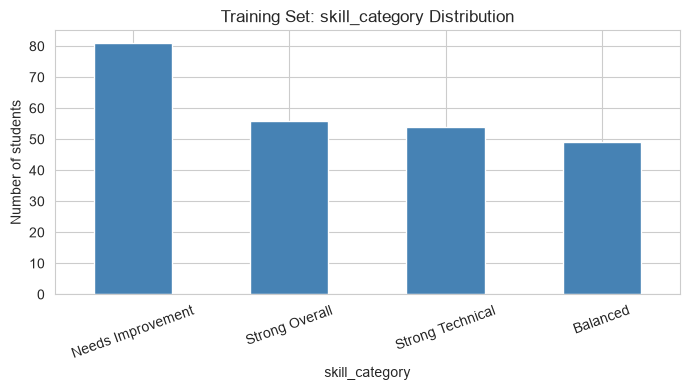

In [5]:
print("y_train class distribution:")
print(y_train.value_counts())
print()
print("y_test class distribution:")
print(y_test.value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
y_train.value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Training Set: skill_category Distribution")
ax.set_xlabel("skill_category")
ax.set_ylabel("Number of students")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Train and Evaluate 5 Classifiers

Each model is trained **only** on `X_train_scaled`/`y_train`, then evaluated by predicting on `X_test_scaled` and comparing against `y_test`. We use simple, sensible default hyperparameters — no `GridSearchCV`, no tuning — since the goal here is a fair comparison, not squeezing out extra performance. `max_iter=1000` on Logistic Regression is just to guarantee it converges, not a form of tuning.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
}

trained_models = {}
predictions = {}
comparison_rows = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    trained_models[name] = model
    predictions[name] = y_pred

    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
    })

print("All 5 models trained on X_train_scaled/y_train and evaluated on X_test_scaled/y_test.")

All 5 models trained on X_train_scaled/y_train and evaluated on X_test_scaled/y_test.


## 7. Model Comparison Table

In [7]:
comparison_table = pd.DataFrame(comparison_rows).sort_values("f1_weighted", ascending=False).reset_index(drop=True)
comparison_table.round(4)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Support Vector Machine,1.0000,1.0000,1.0000,1.0000
1,K-Nearest Neighbors,0.9667,0.9682,0.9667,0.9668
2,Random Forest,0.9667,0.9686,0.9667,0.9665
3,Logistic Regression,0.9667,0.9686,0.9667,0.9653
4,Decision Tree,0.8500,0.8522,0.8500,0.8495


## 8. Class-Wise Performance (Per-Class Precision/Recall/F1)

The overall weighted scores above can hide problems with individual classes (e.g. a model could do great on the largest class and poorly on a smaller one, while still looking good overall). We check each model's per-class report before deciding anything.

In [8]:
category_order = ["Needs Improvement", "Strong Technical", "Balanced", "Strong Overall"]

for name in models:
    print(f"===== {name} =====")
    print(classification_report(y_test, predictions[name], labels=category_order, zero_division=0))

===== Logistic Regression =====
                   precision    recall  f1-score   support

Needs Improvement       0.95      1.00      0.98        21
 Strong Technical       0.93      1.00      0.96        13
         Balanced       1.00      0.80      0.89        10
   Strong Overall       1.00      1.00      1.00        16

         accuracy                           0.97        60
        macro avg       0.97      0.95      0.96        60
     weighted avg       0.97      0.97      0.97        60

===== K-Nearest Neighbors =====
                   precision    recall  f1-score   support

Needs Improvement       1.00      1.00      1.00        21
 Strong Technical       0.92      0.92      0.92        13
         Balanced       0.91      1.00      0.95        10
   Strong Overall       1.00      0.94      0.97        16

         accuracy                           0.97        60
        macro avg       0.96      0.97      0.96        60
     weighted avg       0.97      0.97      0.

## 9. Confusion Matrix — Best-Performing Classifier by Raw Metrics

We show the confusion matrix for whichever model scored highest on weighted F1 in the table above, before deciding whether it is actually our final choice.

Top-scoring model by weighted F1: Support Vector Machine


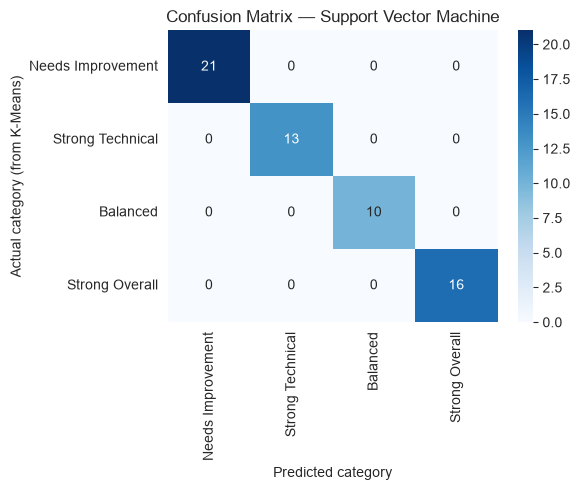

In [9]:
top_by_metrics = comparison_table.iloc[0]["model"]
print(f"Top-scoring model by weighted F1: {top_by_metrics}")

cm_top = confusion_matrix(y_test, predictions[top_by_metrics], labels=category_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_top, annot=True, fmt="d", cmap="Blues",
            xticklabels=category_order, yticklabels=category_order)
plt.title(f"Confusion Matrix — {top_by_metrics}")
plt.xlabel("Predicted category")
plt.ylabel("Actual category (from K-Means)")
plt.tight_layout()
plt.show()

## 10. Why the Scores Are So High (and Why That Isn't Suspicious Here)

Four of the five models score 0.97–1.00 on weighted F1, and Support Vector Machine reaches a perfect 1.00. This is **not** a sign of data leakage or an artificially inflated result — it is an expected consequence of how the labels were created:

K-Means assigns every student to whichever cluster center is closest, in the same scaled feature space these classifiers also use. That means the "true" decision boundaries between categories are already fairly clean, smooth shapes in this feature space (roughly: regions closest to each cluster center) — not messy, real-world-noisy boundaries. A classifier that can find smooth boundaries in continuous numeric space (like SVM, or even Logistic Regression) has an easy time reproducing them almost exactly.

This is exactly the outcome the Stage 4 notebook predicted: *"the classifier is learning to approximate the K-Means-derived student profiles."* High scores here mean the classifier is good at reproducing the clustering — they do **not** mean the model has learned to predict real-world career success or employability, because no real-world outcome was ever part of this dataset.

The one clear exception is **Decision Tree** (0.85 accuracy, 0.85 weighted F1) — a single decision tree makes axis-aligned splits (like "if coding_skill > 6.2"), which can't represent the smoother, angled boundaries K-Means produces as well as the other four models can. This is a helpful, honest data point: it shows the near-perfect scores aren't just "every model gets everything right no matter what" — model choice still matters.

## 11. Final Model Selection Rationale

We deliberately do **not** pick Support Vector Machine just because it scored highest. Considering multiple factors together:

- **Class-wise performance:** Logistic Regression's weakest spot is the "Balanced" class (0.80 recall — it misses 2 of 10 Balanced students). K-Nearest Neighbors dips slightly on "Strong Technical" (0.92 recall) and "Strong Overall" (0.94 recall). **Random Forest** has no class below 0.90 recall, and is perfect (1.00) on both "Needs Improvement" and "Strong Technical" — the most evenly strong performance among the non-perfect models.
- **Interpretability:** Random Forest provides `feature_importances_` — a simple, direct way to show *which skills mattered most* to the categorization, which is valuable both for this project's explainability goal and for justifying the model in a viva. SVM's decision boundary (especially with the default RBF kernel) is comparatively harder to explain simply.
- **Confidence in the near-perfect score:** SVM's perfect 1.00 is explained above as a property of the label's origin, not proof of a better model — with scores this close together (0.9665–1.0000 across four models), a small interpretability and class-balance advantage is a meaningful tiebreaker.
- **Suitability for this project:** Random Forest is a widely taught, easy-to-explain ensemble method ("many decision trees vote"), robust to the kind of moderate feature correlation seen in Stage 2's EDA, and does not require careful preprocessing choices beyond what we've already done.

**Final selection: Random Forest.**

## 12. Confusion Matrix and Feature Importances — Final Selected Model (Random Forest)

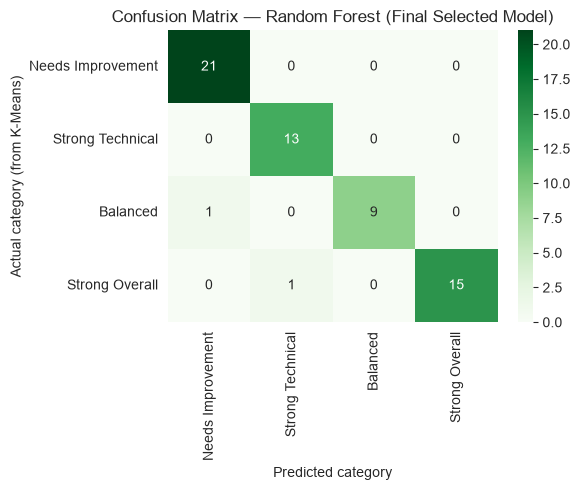

Random Forest feature importances:
security_knowledge      0.196
dsa_skill               0.194
communication_skill     0.179
coding_skill            0.141
certifications_count    0.083
math_aptitude           0.079
projects_count          0.058
cgpa                    0.057
internships_count       0.013
dtype: float64


In [10]:
final_model_name = "Random Forest"
final_model = trained_models[final_model_name]

cm_final = confusion_matrix(y_test, predictions[final_model_name], labels=category_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Greens",
            xticklabels=category_order, yticklabels=category_order)
plt.title(f"Confusion Matrix — {final_model_name} (Final Selected Model)")
plt.xlabel("Predicted category")
plt.ylabel("Actual category (from K-Means)")
plt.tight_layout()
plt.show()

importances = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=False)
print("Random Forest feature importances:")
print(importances.round(3))

## 13. Interpretation of Results

Random Forest reproduces the K-Means categories very well on the held-out test set (weighted accuracy/F1 ≈ 0.97). Out of 60 test students, only 2 are misclassified, and both errors are explainable rather than random:

- One actual **Balanced** student was predicted as **Needs Improvement** — plausible, since Balanced (Cluster 2) is only moderately above the weakest cluster on most features besides its security specialization, so a Balanced student on the lower end of that range can look similar to the weakest group.
- One actual **Strong Overall** student was predicted as **Strong Technical** — also plausible, since both groups share high coding/DSA/math scores; the main difference (Strong Overall's much higher communication score) is exactly the kind of feature a borderline student could sit close to the boundary on.

Every other prediction — including all 21 "Needs Improvement" and all 13 "Strong Technical" test students — is exactly correct. The feature importances also confirm the model is relying on genuine, interpretable skill signals (technical features carrying real weight) rather than an arbitrary or spurious pattern.

## 14. Limitations

- **The target is a pseudo-label, not ground truth.** Every metric in this notebook measures agreement with Stage 4's K-Means clustering, not real-world career readiness, employability, or success. This must be stated clearly wherever these results are reported (report, app, viva).
- **The dataset is synthetic** (documented in `ml/data/raw/DATASET_NOTES.md`), so even the *clustering itself* is based on hand-picked archetypes, not observed real student data. Both the labels and the classifier inherit this limitation.
- **Near-perfect scores are a property of this specific setup** (classifying a K-Means partition of continuous features), not evidence that the model would perform this well on a harder, real-world labeled task.
- **Test set is small** (60 students), so metrics like "1 misclassified Balanced student" swing precision/recall by a relatively large amount (10%). A larger dataset would give more stable estimates.
- **No hyperparameter tuning was performed** (by design, to keep the comparison simple and fair) — a tuned model might behave slightly differently, though given the already near-perfect scores, there is little room for improvement here.

## 15. Save the Final Classifier and Metadata

Only the selected model (Random Forest) is saved. `scaler.pkl` and `kmeans_model.pkl` are not touched.

In [11]:
joblib.dump(final_model, "../models/skill_category_classifier.pkl")

final_metrics = comparison_table[comparison_table["model"] == final_model_name].iloc[0]

classifier_info = {
    "selected_model": final_model_name,
    "feature_list": features,
    "target_name": "skill_category",
    "target_categories": category_order,
    "evaluation_metrics": {
        "accuracy": round(float(final_metrics["accuracy"]), 4),
        "precision_weighted": round(float(final_metrics["precision_weighted"]), 4),
        "recall_weighted": round(float(final_metrics["recall_weighted"]), 4),
        "f1_weighted": round(float(final_metrics["f1_weighted"]), 4),
    },
    "note": (
        "target_categories are K-Means-derived pseudo-labels from Stage 4, "
        "not real-world ground truth. evaluation_metrics measure how well the "
        "classifier reproduces the clustering-based labels, not real-world "
        "career readiness, employability, or success."
    ),
}

with open("../models/classifier_info.json", "w") as f:
    json.dump(classifier_info, f, indent=2)

print("Saved ml/models/skill_category_classifier.pkl")
print("Saved ml/models/classifier_info.json")
print()
print(json.dumps(classifier_info, indent=2))

Saved ml/models/skill_category_classifier.pkl
Saved ml/models/classifier_info.json

{
  "selected_model": "Random Forest",
  "feature_list": [
    "cgpa",
    "coding_skill",
    "dsa_skill",
    "math_aptitude",
    "communication_skill",
    "security_knowledge",
    "projects_count",
    "internships_count",
    "certifications_count"
  ],
  "target_name": "skill_category",
  "target_categories": [
    "Needs Improvement",
    "Strong Technical",
    "Balanced",
    "Strong Overall"
  ],
  "evaluation_metrics": {
    "accuracy": 0.9667,
    "precision_weighted": 0.9686,
    "recall_weighted": 0.9667,
    "f1_weighted": 0.9665
  },
  "note": "target_categories are K-Means-derived pseudo-labels from Stage 4, not real-world ground truth. evaluation_metrics measure how well the classifier reproduces the clustering-based labels, not real-world career readiness, employability, or success."
}


## 16. Leakage Check

- **`generation_reference.csv` was never loaded.** Only `pd.read_csv("../data/raw/student_data.csv")` appears in this notebook (Section 2).
- **K-Means was never fit again.** `kmeans_model` is only loaded via `joblib.load(...)` and used with `.predict()` (Section 4). No `.fit()` or `.fit_predict()` call on any K-Means object appears anywhere in this notebook.
- **The scaler was never refit.** `scaler` is only loaded via `joblib.load(...)` and used with `.transform()` (Section 3).
- **All 5 classifiers were trained only on `X_train_scaled`/`y_train`,** and evaluated only on `X_test_scaled`/`y_test` (Section 6) — no model ever saw the test features during `.fit()`.
- **No labels were created manually.** `y_train`/`y_test` come only from `kmeans_model.predict(...)` mapped through `cluster_category_mapping.json` (Section 4).
- **`scaler.pkl` and `kmeans_model.pkl` were not overwritten** — this notebook only saves new files: `skill_category_classifier.pkl` and `classifier_info.json`.

All checks pass.

## Classification Conclusion

Five classifiers (Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, Support Vector Machine) were trained on `X_train_scaled` and evaluated on `X_test_scaled` against `skill_category` pseudo-labels generated by Stage 4's K-Means model. Support Vector Machine scored highest (perfect 1.00 across all weighted metrics), but was not automatically selected — Section 10 explains why near-perfect scores are expected here rather than suspicious, and Section 11 weighs class-wise performance and interpretability instead of raw score alone.

**Random Forest was selected as the final model**, with weighted accuracy/precision/recall/F1 all ≈0.97, no class below 0.90 recall, only 2 misclassifications out of 60 test students (both explainable via feature overlap between adjacent categories), and the added benefit of interpretable feature importances.

**Restating the key methodological point:** the classifier is learning to approximate the K-Means-derived student profiles for new students. Its evaluation measures how well it reproduces the clustering-based labels, not how accurately it predicts real-world career outcomes. This must not be described as employability prediction, career success prediction, or real career-readiness accuracy anywhere this project is presented.

No classifier was trained on the full dataset before evaluation. `scaler.pkl` and `kmeans_model.pkl` remain exactly as Stage 3 and Stage 4 produced them. Stage 6 (DBSCAN + PCA) and Stage 7 (the rule-based career alignment engine) build on top of this work but are out of scope for this notebook.